# Statistical Analysis

[This notebook](https://github.com/dattalab/keypoint-moseq/blob/main/docs/source/analysis.ipynb) contains routines for analyzing the output of keypoint-MoSeq.

```{note}
The interactive widgets require jupyterlab launched from the `keypoint_moseq` environment. They will not work properly in jupyter notebook.
```


## Setup

We assume you have already have keypoint-MoSeq outputs that are organized as follows.
```
<project_dir>/               ** current working directory
└── <model_name>/            ** model directory
    ├── results.h5           ** model results
    └── grid_movies/         ** [Optional] grid movies folder
```
Use the code below to enter in your project directory and model name.

In [1]:
import keypoint_moseq as kpms
from pathlib import Path
modelFolder = "labels_v003_0.5scaling"
project_dir = str(Path(f"/Users/ramzyalmulla/research/smearlab/kpms_v4"))
model_name = "kpms_model_30fps"


## Assign Groups

The goal of this step is to assign group labels (such as "mutant" or "wildtype") to each recording. These labels are important later for performing group-wise comparisons.
- The code below creates a table called `{project_dir}/index.csv` and launches a widget for editing the table. To use the widget:
    - Click cells in the "group" column and enter new group labels.
    - Hit `Save group info` when you're done.
- **If the widget doesn't appear**, you also edit the table directly in Excel or LibreOffice Calc.

In [2]:

kpms.interactive_group_setting(project_dir, model_name)

Row
    [0] Tabulator(editors={'name': None, ...}, show_index=False, titles={'name': 'recording name',...}, value=              ..., widths={'name': 400})
    [1] Column
        [0] Button(button_type='primary', name='Save group info')

## Generate dataframes

Generate a pandas dataframe called `moseq_df` that contains syllable labels and kinematic information for each frame across all the recording sessions. 

In [13]:
moseq_df = kpms.compute_moseq_df(project_dir, model_name, smooth_heading=True)
moseq_df

,name,centroid_x,centroid_y,heading,angular_velocity,velocity_px_s,syllable,frame_index,group,onset
0,05152026_2208_a14,883.547583,78.715807,-0.080813,0.000000,0.000000,65,0,a,True
1,05152026_2208_a14,885.917195,76.851078,-0.074034,0.121232,90.460215,65,1,a,False
2,05152026_2208_a14,890.436560,77.768942,-0.074034,0.244040,138.348913,65,2,a,False
3,05152026_2208_a14,898.249930,80.952207,-0.074034,0.366382,253.108142,65,3,a,False
4,05152026_2208_a14,905.954694,79.785766,-0.038701,0.480816,233.776776,65,4,a,False
...,...,...,...,...,...,...,...,...,...,...
164471,05152026_2210_a14,279.148764,658.120111,0.055952,-1.120294,29.598119,0,54807,c,False
164472,05152026_2210_a14,281.408505,658.820705,0.039847,-0.862707,70.975622,0,54808,c,False
164473,05152026_2210_a14,285.205284,659.618363,0.039847,-0.606859,116.389880,0,54809,c,False
164474,05152026_2210_a14,285.083043,656.578476,0.039847,-0.376210,91.270331,0,54810,c,False


Next generate a dataframe called `stats_df` that contains summary statistics for each syllable in each recording session, such as its usage frequency and its distribution of kinematic parameters.

In [14]:
stats_df = kpms.compute_stats_df(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.005,  # threshold frequency for including a syllable in the dataframe
    groupby=["group", "name"],  # column(s) to group the dataframe by
    fps=30,
)  # frame rate of the video from which keypoints were inferred

stats_df

,group,name,syllable,heading_mean,heading_std,heading_min,heading_max,angular_velocity_mean,angular_velocity_std,angular_velocity_min,angular_velocity_max,velocity_px_s_mean,velocity_px_s_std,velocity_px_s_min,velocity_px_s_max,frequency,duration
0,a,05152026_2208_a14,0,-0.120757,1.916652,-3.140529,3.140825,-0.027695,7.816917,-188.390593,188.370619,67.669893,36.421555,0.758337,460.390308,0.184789,1.706707
1,a,05152026_2208_a14,1,-0.108417,2.067634,-3.141290,3.141177,-0.575848,17.275859,-188.385352,188.385535,102.807352,64.395161,2.082305,566.842673,0.135211,0.392500
2,a,05152026_2208_a14,2,-0.453979,1.740895,-3.141163,3.134125,-0.013821,13.275432,-187.116143,185.565991,91.719569,58.814012,1.087084,750.663272,0.129577,0.233188
3,a,05152026_2208_a14,3,-0.481753,1.813929,-3.139115,3.135119,-0.008539,9.177995,-188.335404,188.376420,71.193679,37.599065,0.722258,250.941007,0.116056,1.086408
4,a,05152026_2208_a14,4,0.133848,1.761941,-3.140268,3.140771,0.054943,11.415812,-188.157434,188.155739,149.130801,96.159802,1.508442,558.578500,0.088451,0.634183
5,a,05152026_2208_a14,5,-0.890127,1.531047,-3.136406,3.140511,0.171409,9.576358,-187.696047,187.894215,78.252073,47.510130,1.258844,445.268533,0.075493,0.575622
6,a,05152026_2208_a14,6,0.699335,1.834804,-3.128144,3.140825,0.123700,10.090077,-3.642562,187.156062,77.485439,48.479744,4.909895,477.242895,0.019155,0.678431
7,a,05152026_2208_a14,7,-0.906076,2.036939,-3.140979,3.137567,1.353681,21.670102,-188.041687,187.807652,278.433761,154.969593,2.801580,858.309671,0.039437,0.849048
8,a,05152026_2208_a14,8,-0.625608,1.520754,-3.140908,3.141349,-0.020571,7.462150,-188.366710,188.271363,67.384393,36.661305,0.987782,376.449919,0.061972,3.278485
9,a,05152026_2208_a14,9,0.935071,1.721892,-3.141527,3.135662,-1.304064,29.080575,-187.962227,188.041647,854.982679,363.591313,16.443558,1661.136438,0.023662,0.459524


### **Optional:** Save dataframes to csv
Uncomment the code below to save the dataframes as .csv files

In [ ]:
# import os

# # save moseq_df
# save_dir = os.path.join(project_dir, model_name) # directory to save the moseq_df dataframe
# moseq_df.to_csv(os.path.join(save_dir, 'moseq_df.csv'), index=False)
# print('Saved `moseq_df` dataframe to', save_dir)

# # save stats_df
# save_dir = os.path.join(project_dir, model_name)
# stats_df.to_csv(os.path.join(save_dir, 'stats_df'), index=False)
# print('Saved `stats_df` dataframe to', save_dir)

##  Label syllables

The goal of this step is name each syllable (e.g., "rear up" or "walk slowly").
- The code below creates an empty table at `{project_dir}/{model_name}/syll_info.csv` and launches an interactive widget for editing the table. To use the widget:
    - Select a syllable from the dropdown to display its grid movie.
    - Enter a name into the `label` column of the table (and optionally a short description too).
    - When you are done, hit `Save syllable info` at the bottom of the table.
- **If the widget doesn't appear**, you can also edit the file directly in Excel or LibreOffice Calc.

In [8]:
kpms.label_syllables(project_dir, model_name, moseq_df)

Traceback (most recent call last):
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/pyviz_comms/__init__.py", line 341, in _handle_msg
 self._on_msg(msg)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/viewable.py", line 298, in _on_msg
 doc.unhold()
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/bokeh/document/document.py", line 799, in unhold
 self.callbacks.unhold()
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/bokeh/document/callbacks.py", line 396, in unhold
 self.trigger_on_change(event)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/bokeh/document/callbacks.py", line 373, in trigger_on_change
 invoke_with_curdoc(doc, event.callback_invoker)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/bokeh/document/callbacks.py", line 408, in invoke_with_curdoc
 return f()
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/bokeh/util/callback_manager.py", line 191, in invoke
 callback(attr, old, new)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 403, in _comm_change
 state._handle_exception(e)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/io/state.py", line 408, in _handle_exception
 raise exception
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 401, in _comm_change
 self._schedule_change(doc, comm)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 383, in _schedule_change
 self._change_event(doc)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 379, in _change_event
 self._process_events(events)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 318, in _process_events
 self.param.update(**self_events)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/param/parameterized.py", line 1902, in update
 self_._batch_call_watchers()
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/param/parameterized.py", line 2063, in _batch_call_watchers
 self_._execute_watcher(watcher, events)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/param/parameterized.py", line 2025, in _execute_watcher
 watcher.fn(*args, **kwargs)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/param.py", line 842, in _replace_pane
 self._update_inner(new_object)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/pane/base.py", line 471, in _update_inner
 new_pane, internal = self._update_from_object(
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/pane/base.py", line 447, in _update_from_object
 old_object.param.update(**new_params)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/param/parameterized.py", line 1902, in update
 self_._batch_call_watchers()
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/param/parameterized.py", line 2063, in _batch_call_watchers
 self_._execute_watcher(watcher, events)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/param/parameterized.py", line 2025, in _execute_watcher
 watcher.fn(*args, **kwargs)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 308, in _param_change
 self._apply_update(named_events, msg, model, ref)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 240, in _apply_update
 self._update_model(events, msg, root, model, doc, comm)
 File "/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/panel/reactive.py", line 263, in _update_model
 m

Row
    [0] Column
        [0] Select(options=[0, 1, 2, 3, 4, ...], value=0)
        [1] ParamFunction(function, _pane=Video)
    [1] Column
        [0] Tabulator(editors={'name': None, ...}, show_index=False, titles={'syllable': 'syllable', ...}, value=    syllable l..., widths={'syllable': 100})
        [1] Column
            [0] Button(button_type='primary', name='Save syllable info')

## Compare between groups

Test for statistically significant differences between groups of recordings. The code below takes a syllable property (e.g. frequency or duration), plots its disribution for each syllable across for each group, and also tests whether the property differs significantly between groups. The results are summarized in a plot that is saved to `{project_dir}/{model_name}/analysis_figures`.

There are two options for setting the order of syllables along the x-axis. When `order='stat'`, syllables are sorted by the mean value of the statistic. When `order='diff'`, syllables are sorted by the magnitude of difference between two groups that are determined by the `ctrl_group` and `exp_group` keywords. Note `ctrl_group` and `exp_group` are not related to significance testing.

Saved figure to /Users/ramzyalmulla/research/smearlab/kpms_v4/kpms_model_30fps/figures/frequency_stat_stats.png


When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.Wh

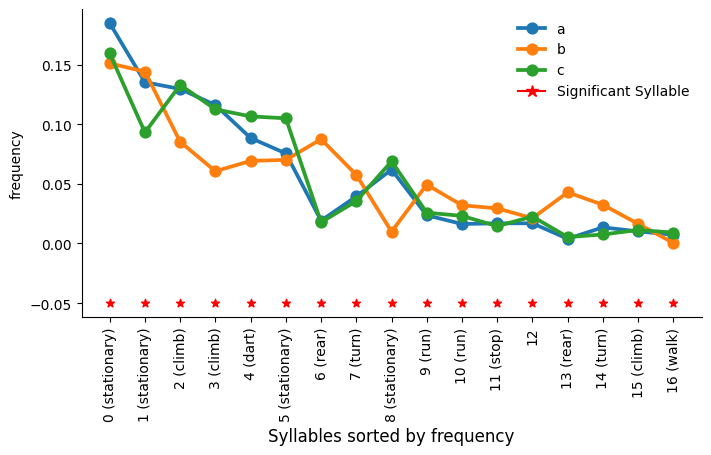

In [15]:
kpms.plot_syll_stats_with_sem(
    stats_df,
    project_dir,
    model_name,
    plot_sig=True,  # whether to mark statistical significance with a star
    thresh=0.05,  # significance threshold
    stat="frequency",  # statistic to be plotted (e.g. 'duration' or 'velocity_px_s_mean')
    order="stat",  # order syllables by overall frequency ("stat") or degree of difference ("diff")
    ctrl_group="a",  # name of the control group for statistical testing
    exp_group="b",  # name of the experimental group for statistical testing
    figsize=(8, 4),  # figure size
    groups=stats_df["group"].unique(),  # groups to be plotted
);

### Transition matrices
Generate heatmaps showing the transition frequencies between syllables.

Group(s): a, b, c
Saved figure to /Users/ramzyalmulla/research/smearlab/kpms_v4/kpms_model_30fps/figures/transition_matrices.png


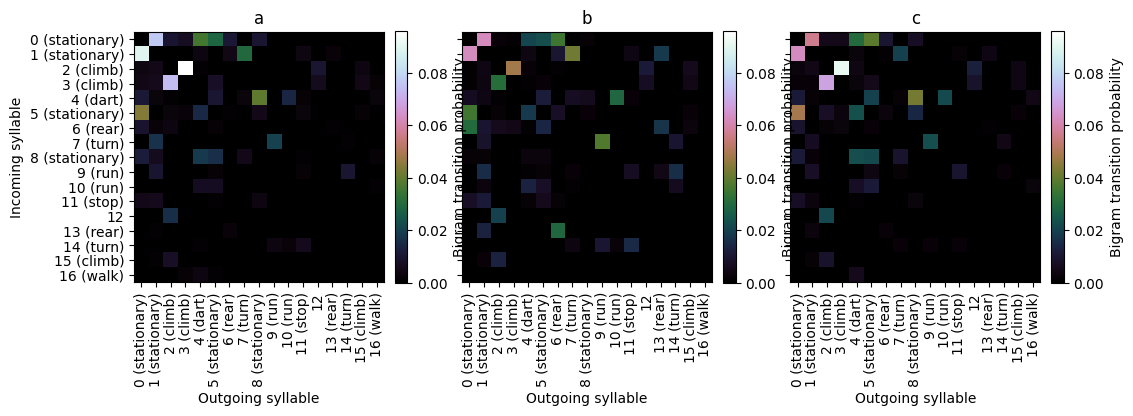

In [16]:
normalize = "bigram"  # normalization method ("bigram", "rows" or "columns")

trans_mats, usages, groups, syll_include = kpms.generate_transition_matrices(
    project_dir,
    model_name,
    normalize=normalize,
    min_frequency=0.005,  # minimum syllable frequency to include
)

kpms.visualize_transition_bigram(
    project_dir,
    model_name,
    groups,
    trans_mats,
    syll_include,
    normalize=normalize,
    show_syllable_names=True,  # label syllables by index (False) or index and name (True)
)

### Syllable Transition Graph
Render transition rates in graph form, where nodes represent syllables and edges represent transitions between syllables, with edge width showing transition rate for each pair of syllables (secifically the max of the two transition rates in each direction).

Saved figure to /Users/ramzyalmulla/research/smearlab/kpms_v4/kpms_model_30fps/figures/transition_graphs.png


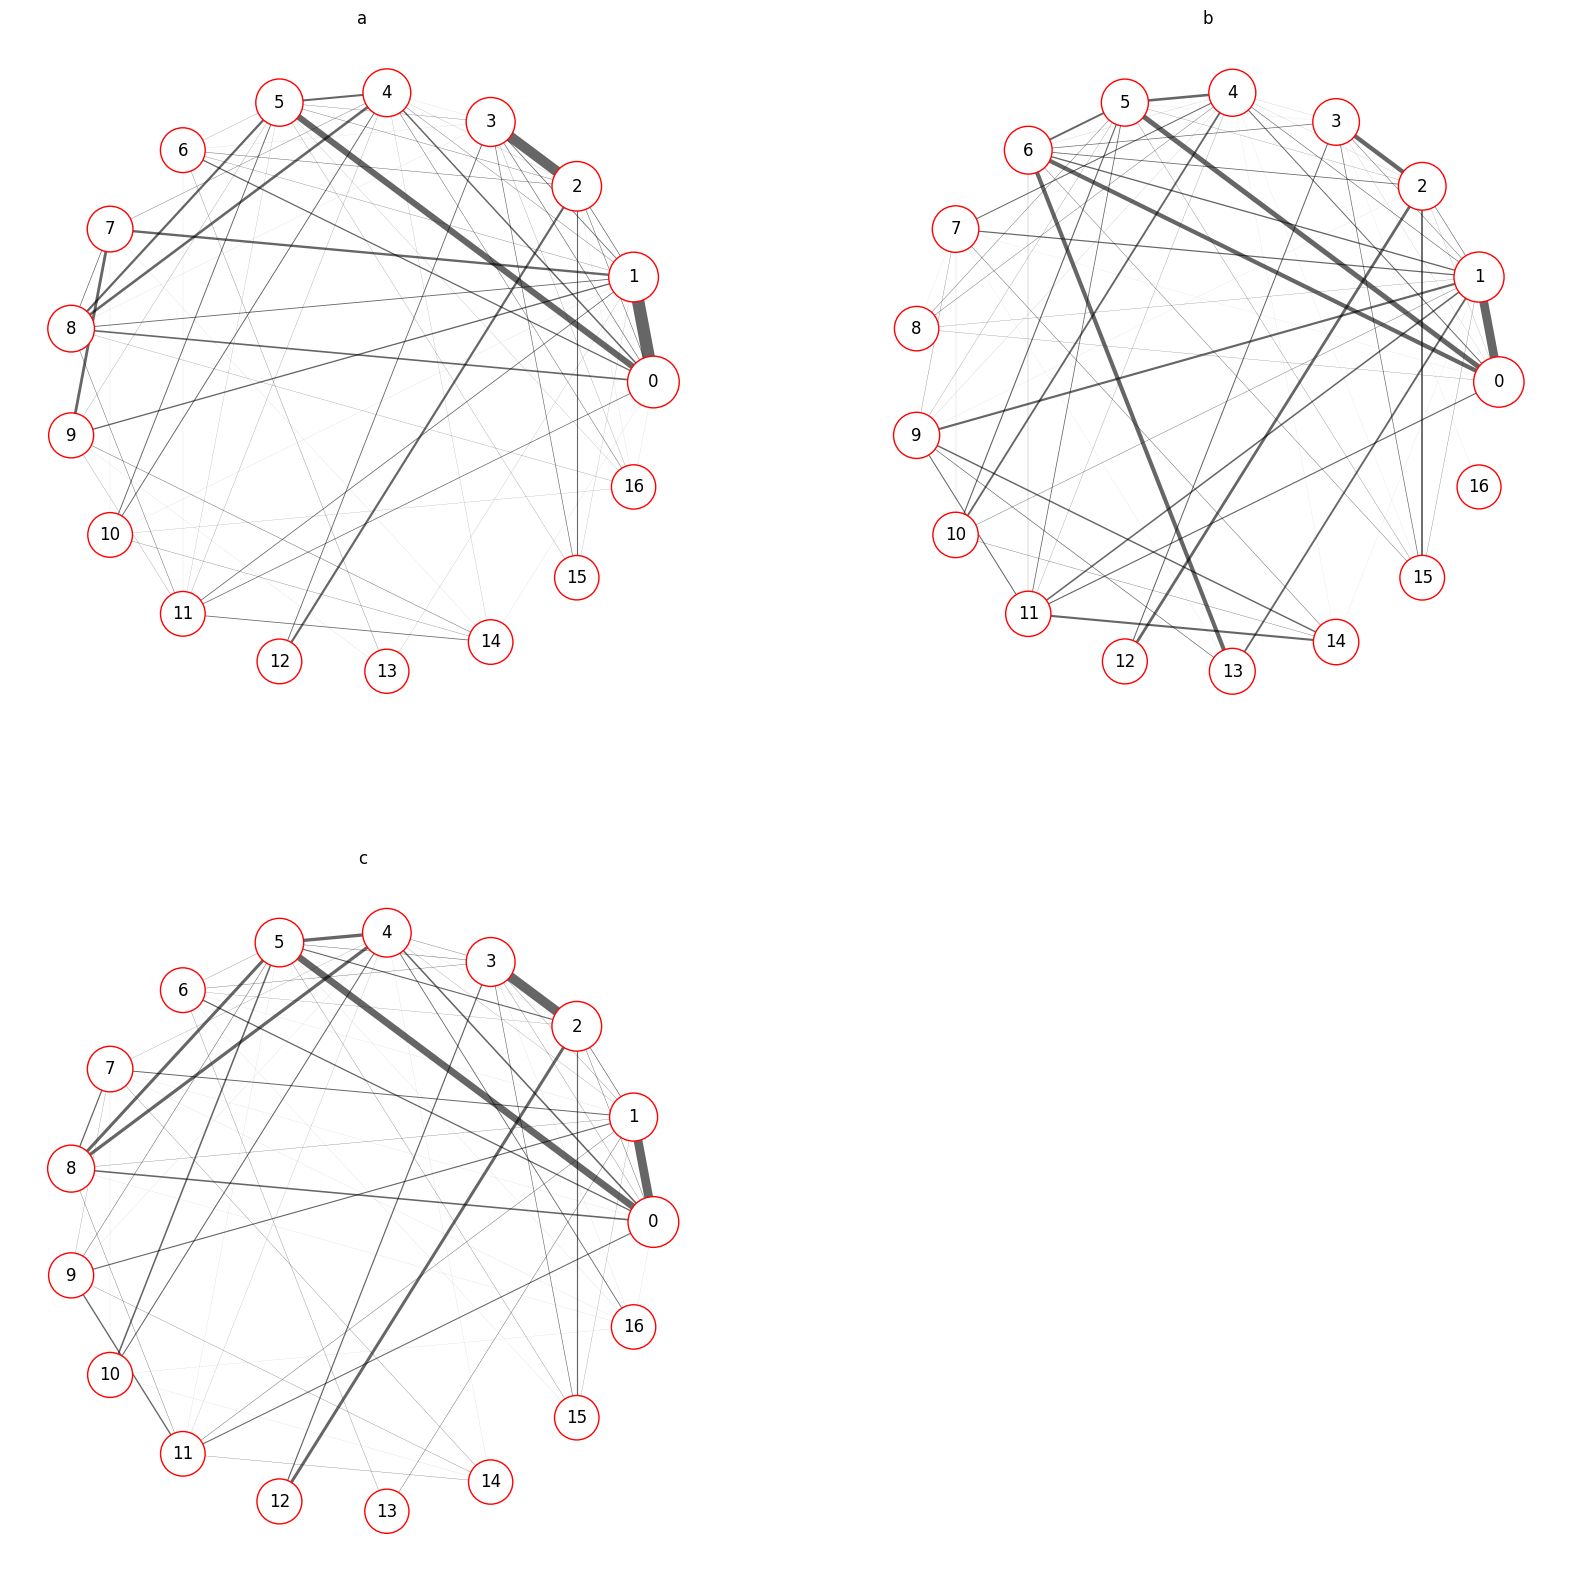

In [17]:
# Generate a transition graph for each single group

kpms.plot_transition_graph_group(
    project_dir,
    model_name,
    groups,
    trans_mats,
    usages,
    syll_include,
    layout="circular",  # transition graph layout ("circular" or "spring")
    show_syllable_names=False,  # label syllables by index (False) or index and name (True)
)

Saved figure to /Users/ramzyalmulla/research/smearlab/kpms_v4/kpms_model_30fps/figures/transition_graphs_diff.png


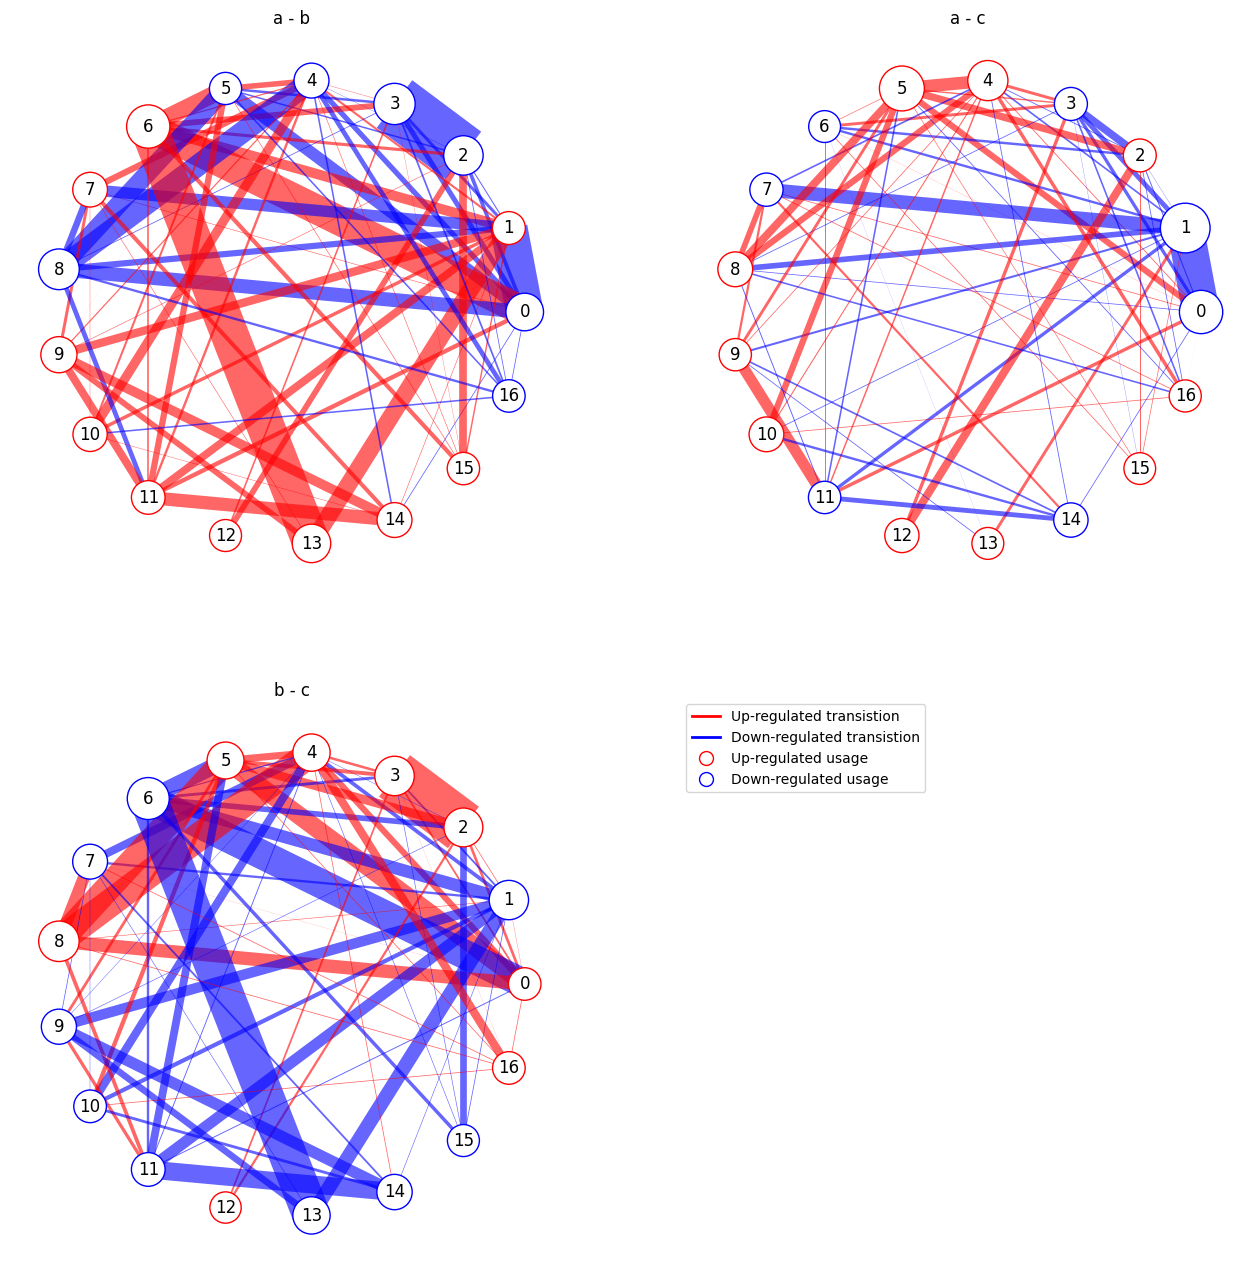

In [18]:
# Generate a difference-graph for each pair of groups.

kpms.plot_transition_graph_difference(
    project_dir, model_name, groups, trans_mats, usages, syll_include, layout="circular"
)  # transition graph layout ("circular" or "spring")

Saved figure to /Users/ramzyalmulla/research/smearlab/kpms_v4/kpms_model_30fps/figures/frequency_stat_stats.png


When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.Wh

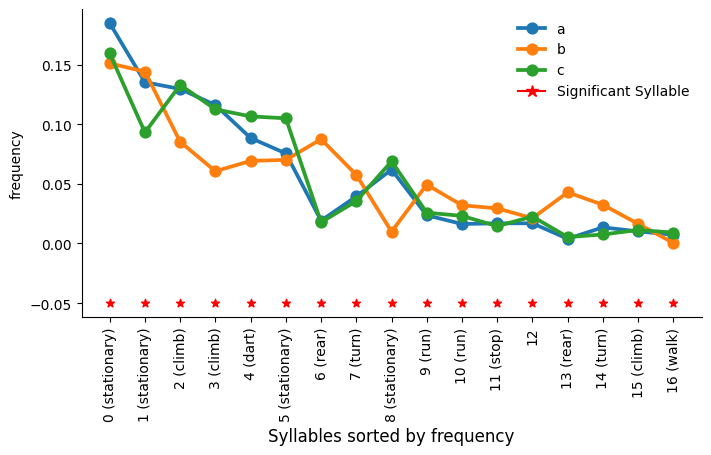

In [19]:
kpms.plot_syll_stats_with_sem(
    stats_df,
    project_dir,
    model_name,
    plot_sig=True,  # whether to mark statistical significance with a star
    thresh=0.05,  # significance threshold
    stat="frequency",  # statistic to be plotted (e.g. 'duration' or 'velocity_px_s_mean')
    order="stat",  # order syllables by overall frequency ("stat") or degree of difference ("diff")
    ctrl_group="a",  # name of the control group for statistical testing
    exp_group="b",  # name of the experimental group for statistical testing
    figsize=(8, 4),  # figure size
    groups=stats_df["group"].unique(),  # groups to be plotted
);